In [265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [266]:
data = pd.read_csv("weather_classification_data.csv")
data.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [267]:
data.isnull().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

In [268]:
data.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
13195    False
13196    False
13197    False
13198    False
13199    False
Length: 13200, dtype: bool

In [269]:
data['Weather Type'].value_counts()

Weather Type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64

In [270]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [271]:
data.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [272]:
l_encoder = LabelEncoder()
data['Weather Type'] = l_encoder.fit_transform(data['Weather Type'])

In [273]:
print(data['Season'].value_counts())
print(data['Location'].value_counts())
print(data['Cloud Cover'].value_counts())


Season
Winter    5610
Spring    2598
Autumn    2500
Summer    2492
Name: count, dtype: int64
Location
inland      4816
mountain    4813
coastal     3571
Name: count, dtype: int64
Cloud Cover
overcast         6090
partly cloudy    4560
clear            2139
cloudy            411
Name: count, dtype: int64


In [274]:
for i in data.columns:
    if data[i].dtype == object:
        encoder = OneHotEncoder(sparse_output=False)
        encoded = encoder.fit_transform(data[[i]])
        encoded_df = pd.DataFrame(encoded,columns=encoder.get_feature_names_out([i]))
        data = pd.concat([data,encoded_df],axis=1)
        data.drop(i,axis=1,inplace=True)

In [275]:
data.head(10)

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Weather Type,Cloud Cover_clear,Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Location_coastal,Location_inland,Location_mountain
0,14.0,73,9.5,82.0,1010.82,2,3.5,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,39.0,96,8.5,71.0,1011.43,7,10.0,0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,30.0,64,7.0,16.0,1018.72,5,5.5,3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,38.0,83,1.5,82.0,1026.25,7,1.0,3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,27.0,74,17.0,66.0,990.67,1,2.5,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
5,32.0,55,3.5,26.0,1010.03,2,5.0,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6,-2.0,97,8.0,86.0,990.87,1,4.0,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
7,3.0,85,6.0,96.0,984.46,1,3.5,2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
8,3.0,83,6.0,66.0,999.44,0,1.0,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
9,28.0,74,8.5,107.0,1012.13,8,7.5,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [276]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Temperature                13200 non-null  float64
 1   Humidity                   13200 non-null  int64  
 2   Wind Speed                 13200 non-null  float64
 3   Precipitation (%)          13200 non-null  float64
 4   Atmospheric Pressure       13200 non-null  float64
 5   UV Index                   13200 non-null  int64  
 6   Visibility (km)            13200 non-null  float64
 7   Weather Type               13200 non-null  int64  
 8   Cloud Cover_clear          13200 non-null  float64
 9   Cloud Cover_cloudy         13200 non-null  float64
 10  Cloud Cover_overcast       13200 non-null  float64
 11  Cloud Cover_partly cloudy  13200 non-null  float64
 12  Season_Autumn              13200 non-null  float64
 13  Season_Spring              13200 non-null  flo

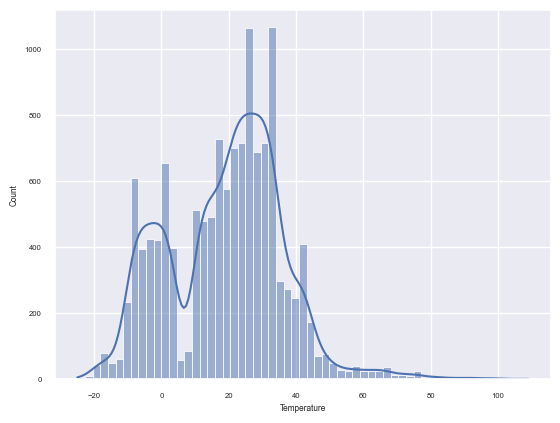

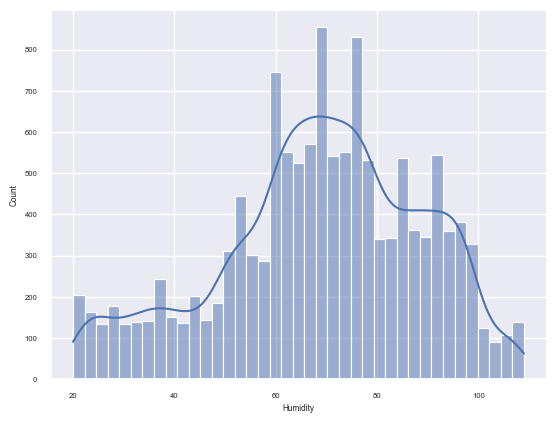

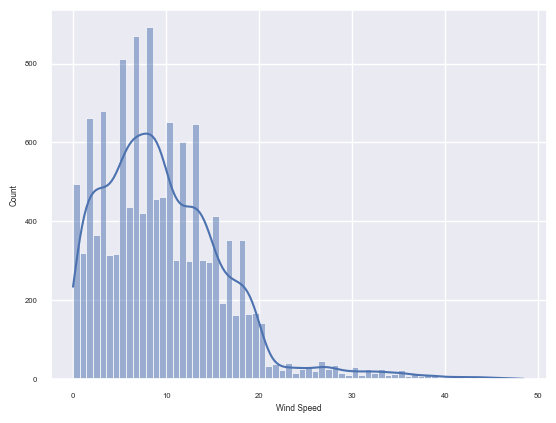

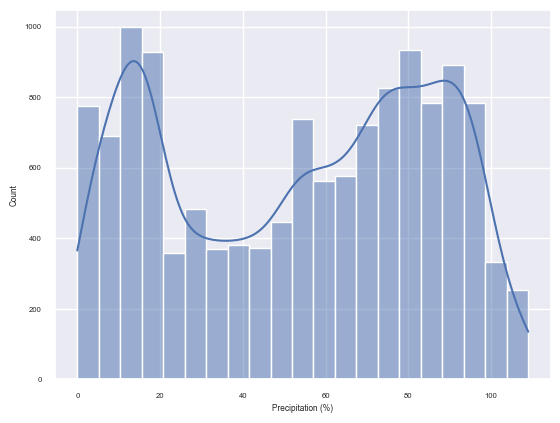

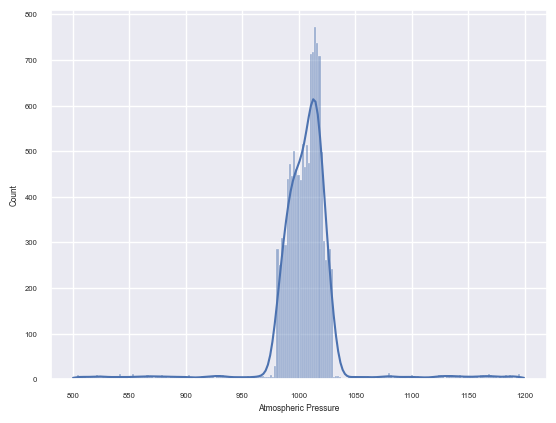

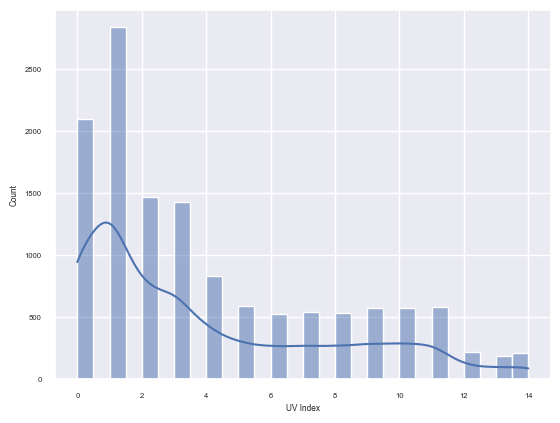

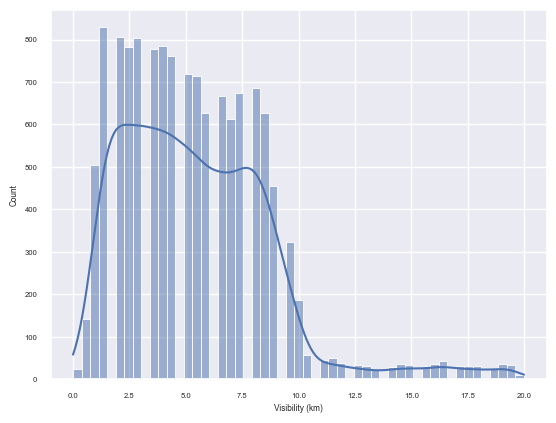

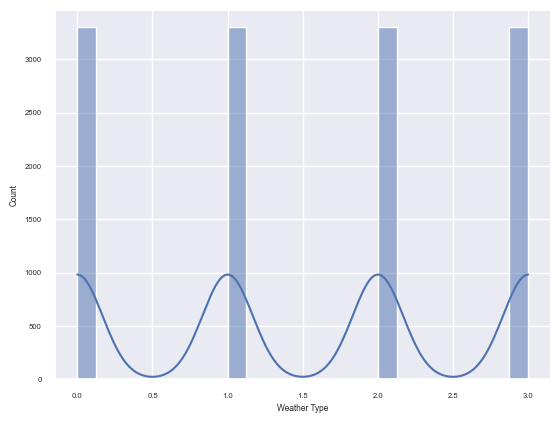

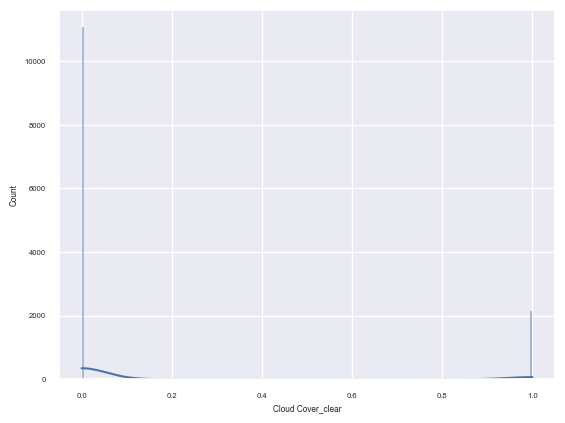

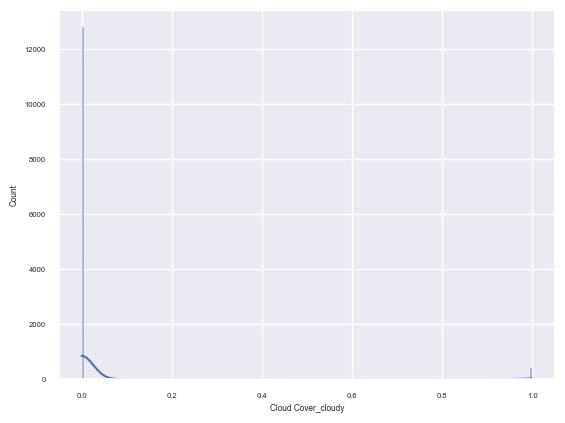

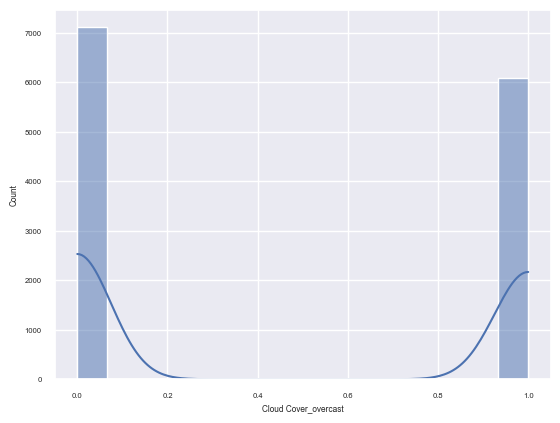

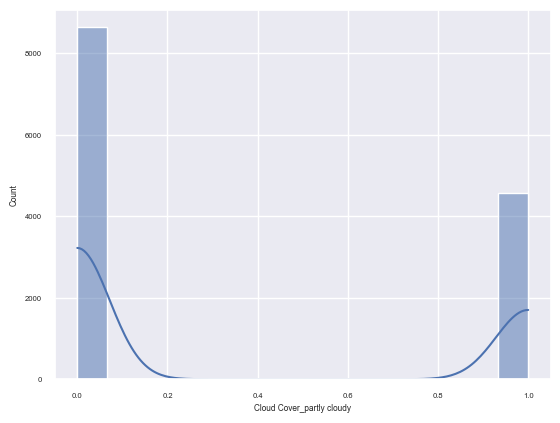

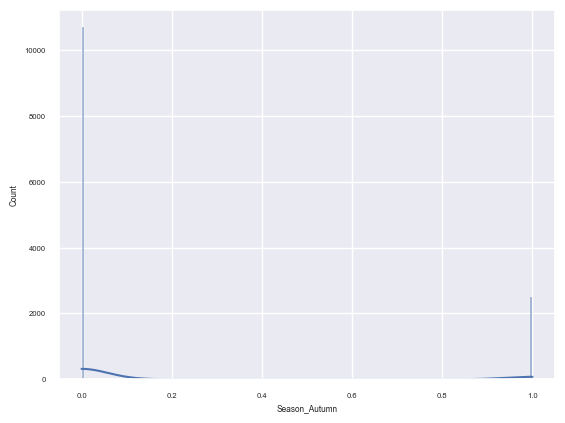

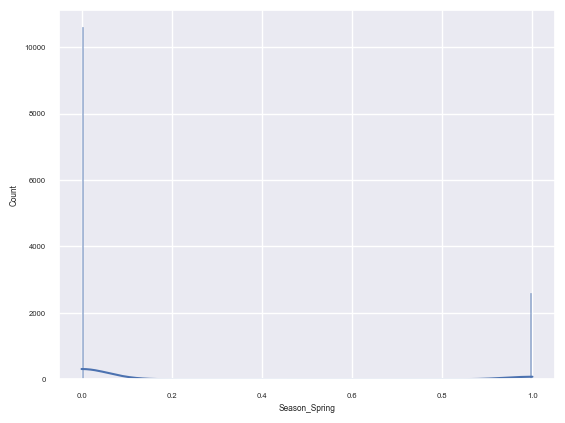

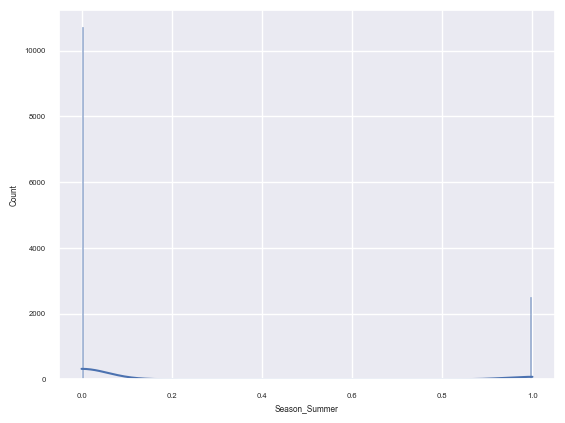

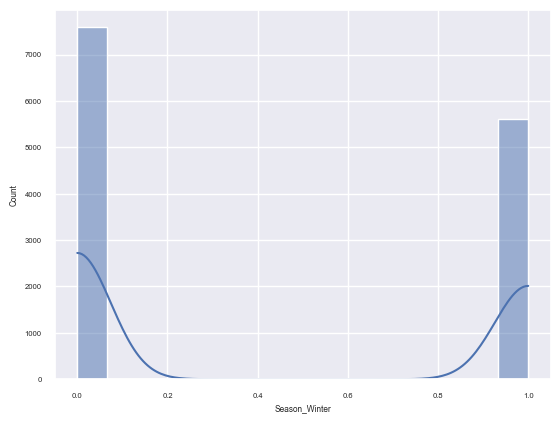

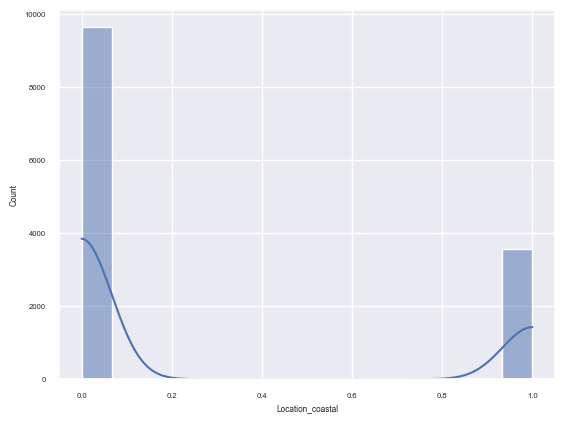

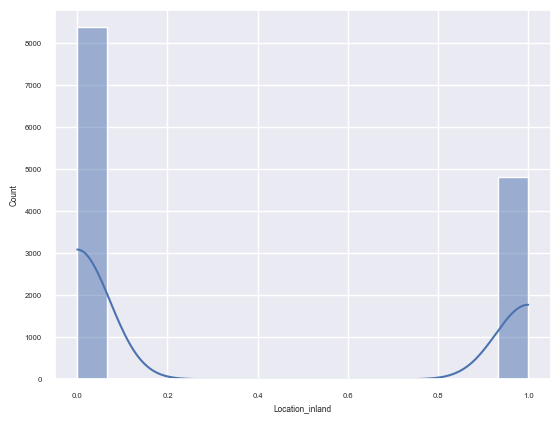

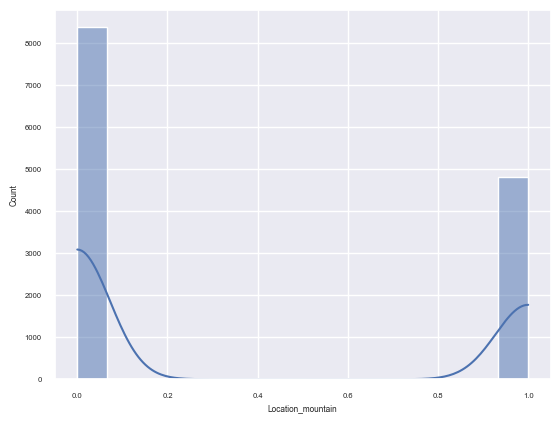

In [277]:
for i in data.columns:
    plt.Figure(figsize=(3,3))
    sns.histplot(data[i],kde=True)
    plt.show()

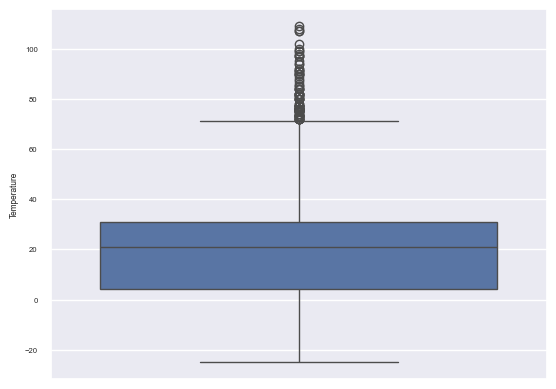

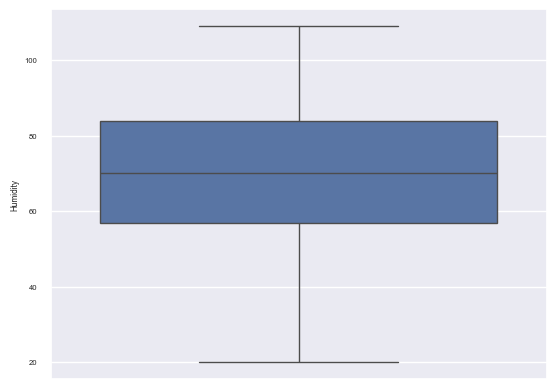

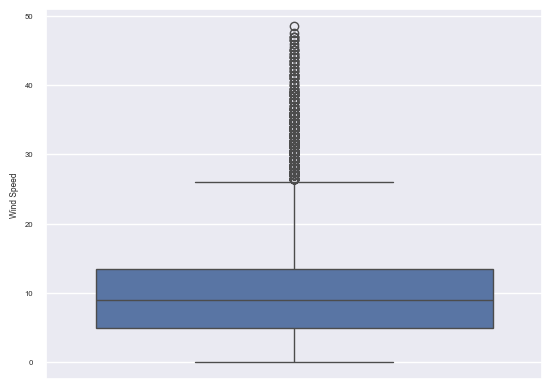

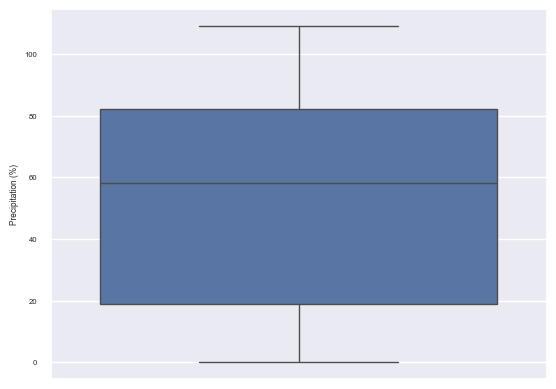

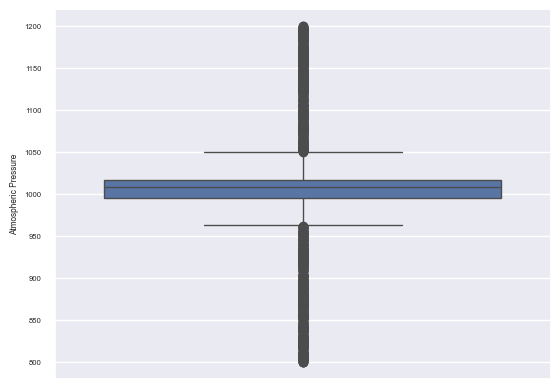

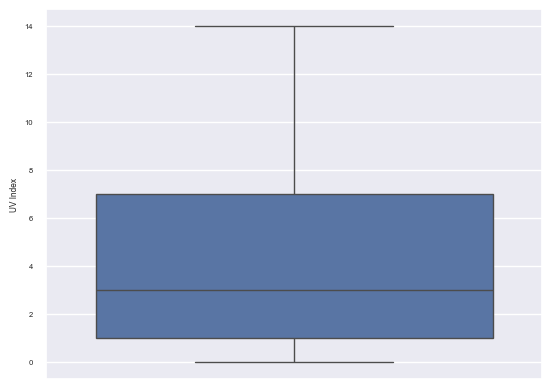

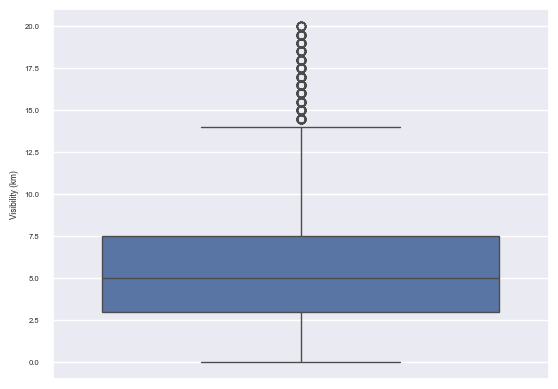

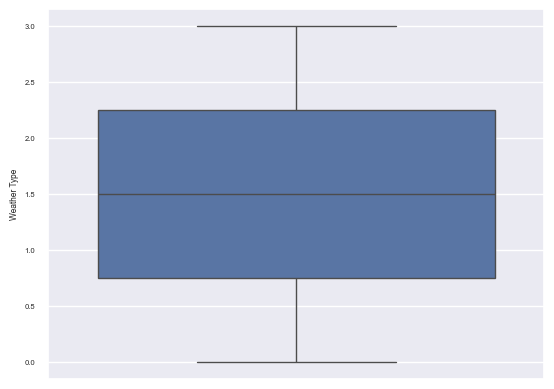

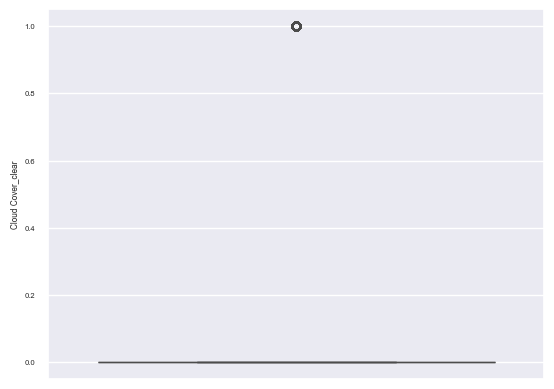

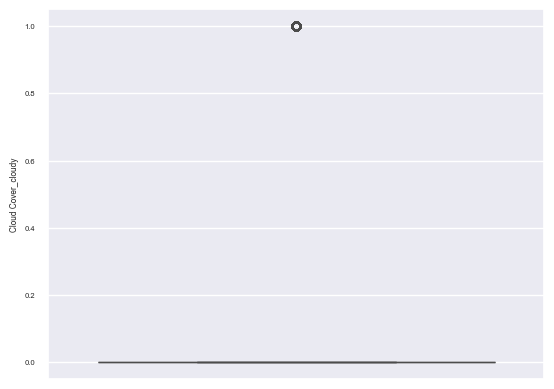

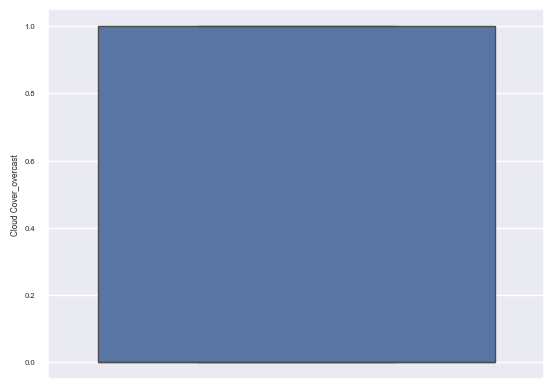

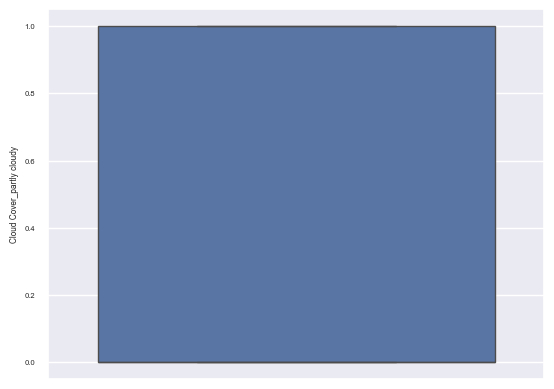

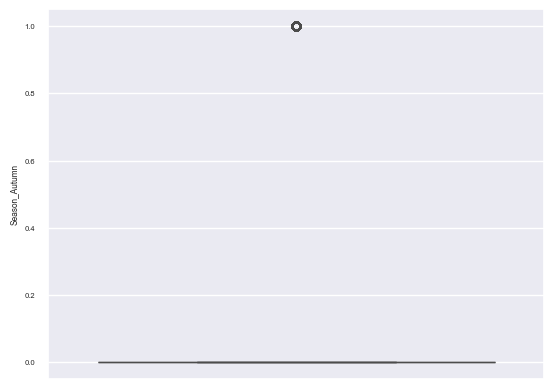

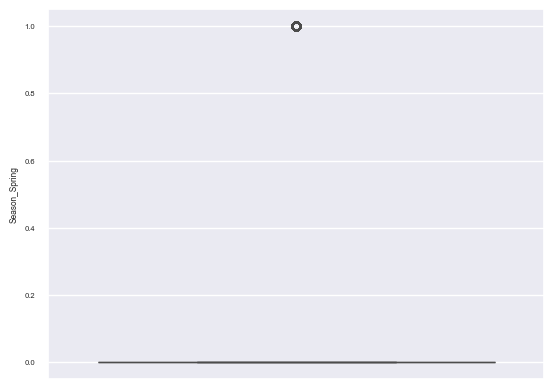

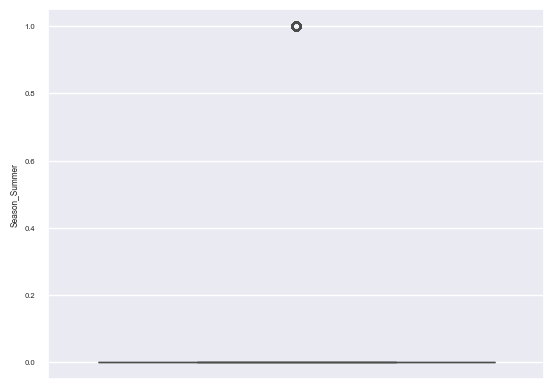

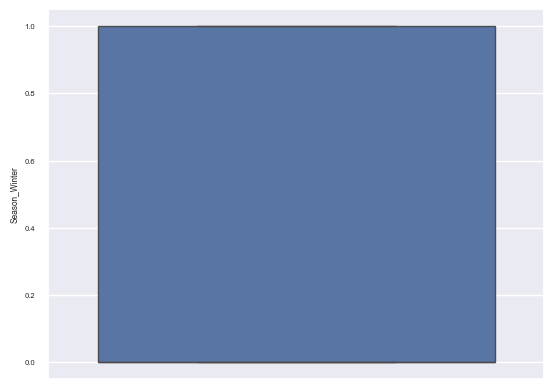

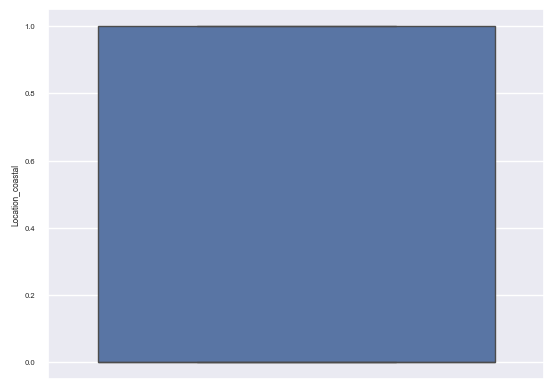

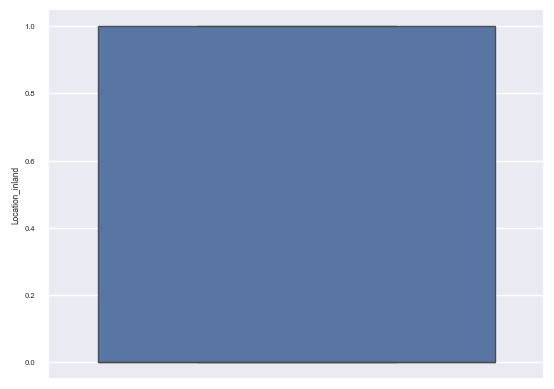

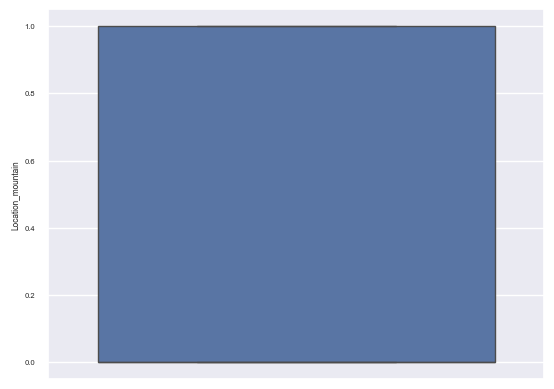

In [278]:
for i in data.columns:
    sns.boxplot(data[i])
    #plt.title(data[i])
    plt.show()

- Outliers in Temperature, Wind Speed, and Visibility are not removed because Decision Trees are robust to them and these values represent real-world variations.
- Outliers in Atmospheric Pressure are handled because they fall outside realistic physical ranges, indicating possible data errors.

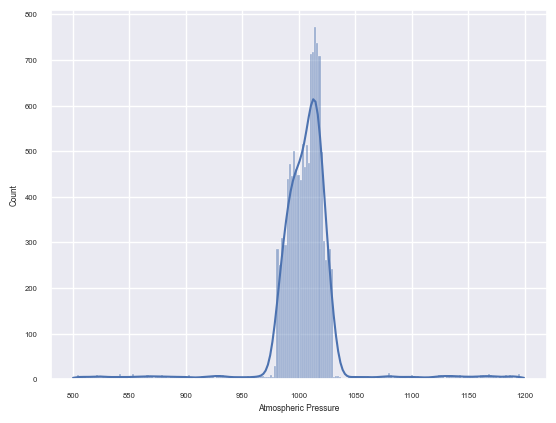

In [279]:
sns.histplot(data['Atmospheric Pressure'],kde=True)
plt.show()

In [280]:
mean = data['Atmospheric Pressure'].mean()
std = data['Atmospheric Pressure'].std()
low_lim = mean - 3 * std
uppr_lim = mean + 3 * std
data['Atmospheric Pressure'] = data['Atmospheric Pressure'].clip(lower=low_lim,upper=uppr_lim)

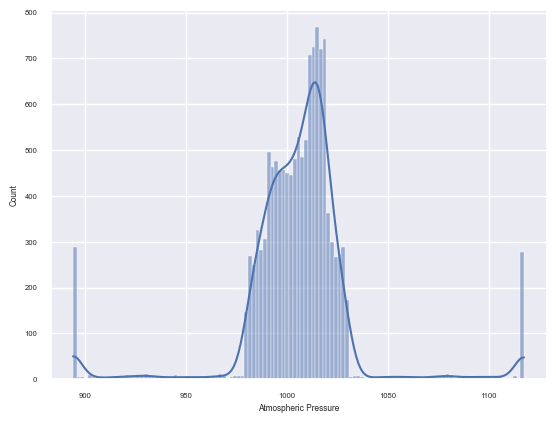

In [281]:
sns.histplot(data['Atmospheric Pressure'],kde=True)
plt.show()

In [282]:
data.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Weather Type,Cloud Cover_clear,Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Location_coastal,Location_inland,Location_mountain
0,14.0,73,9.5,82.0,1010.82,2,3.5,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,39.0,96,8.5,71.0,1011.43,7,10.0,0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,30.0,64,7.0,16.0,1018.72,5,5.5,3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,38.0,83,1.5,82.0,1026.25,7,1.0,3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,27.0,74,17.0,66.0,990.67,1,2.5,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


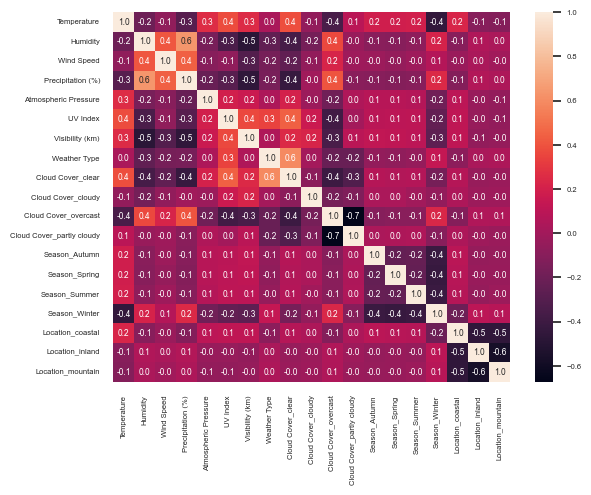

In [283]:
sns.set(font_scale=0.5)
plt.Figure(figsize=(10,8))
sns.heatmap(data.corr(),fmt='.1f',annot=True)
plt.show()

In [284]:
corr = data.corr()['Weather Type'].abs() > 0.7
print(corr)

Temperature                  False
Humidity                     False
Wind Speed                   False
Precipitation (%)            False
Atmospheric Pressure         False
UV Index                     False
Visibility (km)              False
Weather Type                  True
Cloud Cover_clear            False
Cloud Cover_cloudy           False
Cloud Cover_overcast         False
Cloud Cover_partly cloudy    False
Season_Autumn                False
Season_Spring                False
Season_Summer                False
Season_Winter                False
Location_coastal             False
Location_inland              False
Location_mountain            False
Name: Weather Type, dtype: bool


In [285]:
x = data.drop('Weather Type',axis=1)
y = data['Weather Type']

In [286]:
selected_features = x.columns.tolist()
print(selected_features)

['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)', 'Cloud Cover_clear', 'Cloud Cover_cloudy', 'Cloud Cover_overcast', 'Cloud Cover_partly cloudy', 'Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Location_coastal', 'Location_inland', 'Location_mountain']


In [287]:
print(x.shape)
print(y.shape)

(13200, 18)
(13200,)


In [288]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [289]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(x_test.shape)

(9240, 18)
(3960, 18)
(9240,)
(3960, 18)


In [290]:
model1 = DecisionTreeClassifier(criterion='entropy',max_depth=18,min_samples_split=10,min_samples_leaf=5,max_features='sqrt',random_state=42)
model2 = DecisionTreeClassifier(criterion='gini',max_depth=25,min_samples_split=15,min_samples_leaf=5,max_features='sqrt',random_state=42)
model3 = DecisionTreeClassifier(criterion='log_loss',max_depth=30,min_samples_split=20,min_samples_leaf=5,max_features='sqrt',random_state=42)


In [291]:
model1.fit(x_train,y_train)
model2.fit(x_train,y_train)
model3.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'log_loss'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",'sqrt'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

In [292]:
y_pred1 = model1.predict(x_test)
y_pred2 = model2.predict(x_test)
y_pred3 = model3.predict(x_test)

In [293]:
print('Model1: ',classification_report(y_test,y_pred1))

Model1:                precision    recall  f1-score   support

           0       0.87      0.89      0.88       955
           1       0.89      0.90      0.89       982
           2       0.92      0.94      0.93      1033
           3       0.95      0.90      0.92       990

    accuracy                           0.91      3960
   macro avg       0.91      0.91      0.91      3960
weighted avg       0.91      0.91      0.91      3960



In [294]:
print('Model2: ',classification_report(y_test,y_pred2))

Model2:                precision    recall  f1-score   support

           0       0.87      0.87      0.87       955
           1       0.89      0.89      0.89       982
           2       0.92      0.93      0.92      1033
           3       0.91      0.90      0.90       990

    accuracy                           0.90      3960
   macro avg       0.90      0.90      0.90      3960
weighted avg       0.90      0.90      0.90      3960



In [295]:
print('Model3: ',classification_report(y_test,y_pred3))

Model3:                precision    recall  f1-score   support

           0       0.88      0.88      0.88       955
           1       0.90      0.89      0.90       982
           2       0.91      0.94      0.93      1033
           3       0.92      0.89      0.91       990

    accuracy                           0.90      3960
   macro avg       0.90      0.90      0.90      3960
weighted avg       0.90      0.90      0.90      3960



<Axes: >

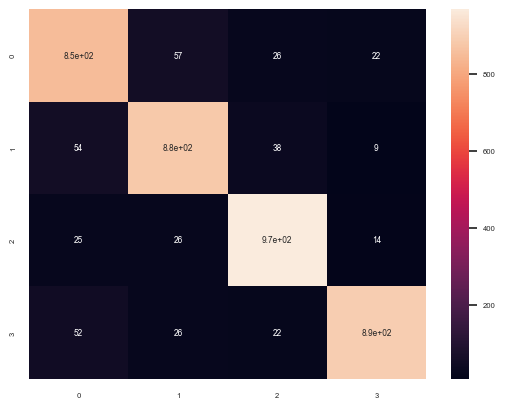

In [296]:
sns.heatmap(confusion_matrix(y_test,y_pred1),annot=True)

<Axes: >

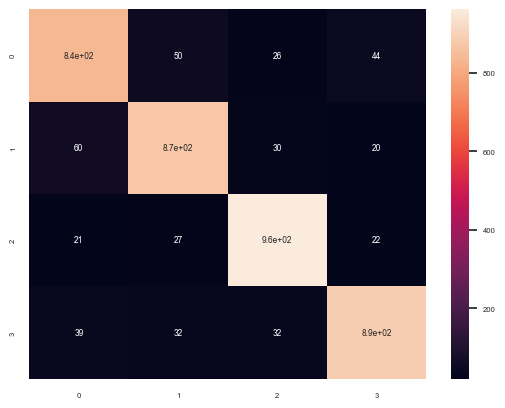

In [297]:
sns.heatmap(confusion_matrix(y_test,y_pred2),annot=True)

<Axes: >

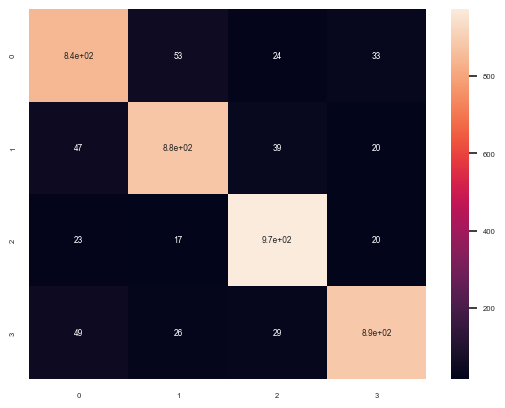

In [298]:
sns.heatmap(confusion_matrix(y_test,y_pred3),annot=True)

In [299]:
from sklearn.metrics import f1_score
f1_m1 = f1_score(y_test,y_pred1,average='weighted')
f1_m2 = f1_score(y_test,y_pred2,average='weighted')
f1_m3 = f1_score(y_test,y_pred3,average='weighted')
print(f1_m1)
print(f1_m2)
print(f1_m3)

0.9064896334808266
0.8981838811780911
0.9039827435085724


In [300]:
print(model1.score(x_train, y_train))
print(model1.score(x_test, y_test))

0.9453463203463204
0.9063131313131313


In [301]:
print(model2.score(x_train, y_train))
print(model2.score(x_test, y_test))

0.9427489177489178
0.8982323232323233


In [302]:
print(model3.score(x_train, y_train))
print(model3.score(x_test, y_test))

0.9353896103896104
0.9040404040404041


In [310]:
import joblib
joblib.dump(model1,'D:\\AI Learning\\weather_classification_data\\model\\weather_classification1.pkl')

['D:\\AI Learning\\weather_classification_data\\model\\weather_classification1.pkl']

In [311]:
joblib.dump(model2,'D:\\AI Learning\\weather_classification_data\\model\\weather_classification2.pkl')

['D:\\AI Learning\\weather_classification_data\\model\\weather_classification2.pkl']

In [312]:
joblib.dump(model3,'D:\\AI Learning\\weather_classification_data\\model\\weather_classification3.pkl')

['D:\\AI Learning\\weather_classification_data\\model\\weather_classification3.pkl']

In [313]:
joblib.dump(encoder,'D:\\AI Learning\\weather_classification_data\\model\\encoder.pkl')

['D:\\AI Learning\\weather_classification_data\\model\\encoder.pkl']

In [314]:
joblib.dump(selected_features,'D:\\AI Learning\\weather_classification_data\\model\\features.pkl')

['D:\\AI Learning\\weather_classification_data\\model\\features.pkl']